# Midnight and Noon Profiles

This notebook handles identification, post-processing, and validation of
noon (pp01) and midnight (pp02) profile subsets.

**Cells:**
1. Identify noon/midnight profiles and generate metadata CSVs
2. Generate pp01/pp02 subsets from redux shards
3. Validation: descent duration anomalies and missing pH/pCO2
4. Depth histograms for pp01/pp02

## Cell 1: Identify noon and midnight profiles

Reads profileIndices, classifies profiles by local peak hour, writes:
- `~/ooi/metadata/ooi_rca_sb_noon_global_profile_indices.csv`
- `~/ooi/metadata/ooi_rca_sb_midnight_global_profile_indices.csv`
- `~/ooi/visualizations/SlopeBaseProfileHistograms.png`

Found 12 RS01SBPS profileIndices files
Total profiles loaded: 22129
Date range: 2015-07-09 16:19:00 to 2026-01-02 10:04:00
Profiles with valid durations: 22129


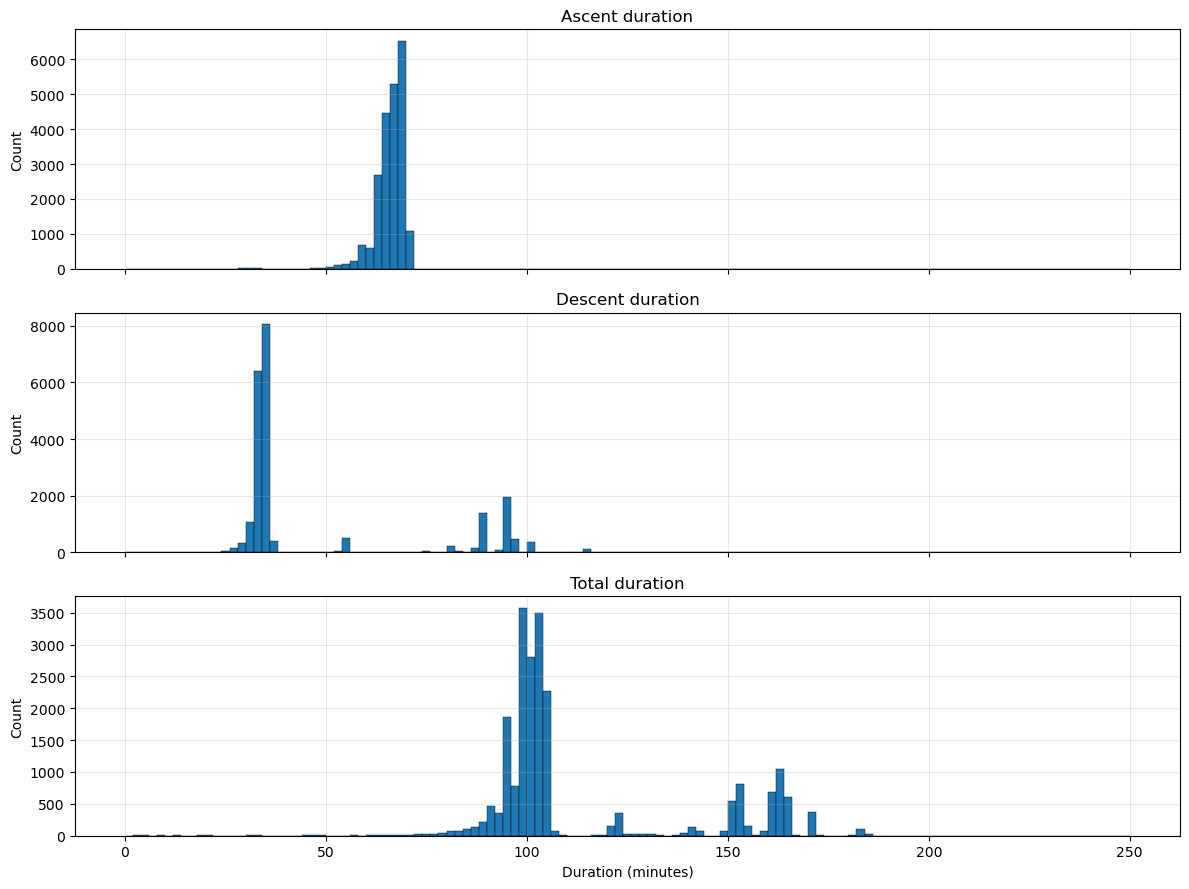

Chart saved to /home/rob/ooi/visualizations/SlopeBaseProfileHistograms.png

Found 2443 midnight profiles out of 3830 possible
Found 2480 noon profiles out of 3830 possible


In [1]:
# Identify noon and midnight profiles from profileIndices
# This is equivalent to running ~/argosy/profile_duration_histograms.py
%matplotlib inline

import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from zoneinfo import ZoneInfo
from pathlib import Path

# Config
SITE_TZ = ZoneInfo("America/Los_Angeles")
PROFILE_INDICES_DIR = Path.home() / "ooi/profileIndices"
SITE_PATTERN = "RS01SBPS_profiles_*.csv"
OUTPUT_PNG = Path.home() / "ooi/visualizations/SlopeBaseProfileHistograms.png"
OUT_MIDNIGHT = Path.home() / "ooi/metadata/ooi_rca_sb_midnight_global_profile_indices.csv"
OUT_NOON = Path.home() / "ooi/metadata/ooi_rca_sb_noon_global_profile_indices.csv"
MIN_GAP_HOURS = 20.0

# Load all RS01SBPS profileIndices files
files = sorted(glob.glob(str(PROFILE_INDICES_DIR / SITE_PATTERN)))
print(f"Found {len(files)} RS01SBPS profileIndices files")

frames = [pd.read_csv(f, parse_dates=["start", "peak", "end"]) for f in files]
pi = pd.concat(frames, ignore_index=True).sort_values("start").reset_index(drop=True)
print(f"Total profiles loaded: {len(pi)}")
print(f"Date range: {pi['start'].min()} to {pi['end'].max()}")

# Compute durations
pi["ascent_min"] = (pi["peak"] - pi["start"]).dt.total_seconds() / 60.0
pi["descent_min"] = (pi["end"] - pi["peak"]).dt.total_seconds() / 60.0
pi["total_min"] = (pi["end"] - pi["start"]).dt.total_seconds() / 60.0

valid = pi[(pi["ascent_min"] > 0) & (pi["descent_min"] > 0)].copy()
print(f"Profiles with valid durations: {len(valid)}")

# Histograms
bins = np.arange(0, 252, 2)
fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)
for ax, col, title in zip(axes, ["ascent_min", "descent_min", "total_min"],
                           ["Ascent duration", "Descent duration", "Total duration"]):
    ax.hist(valid[col], bins=bins, edgecolor="black", linewidth=0.3)
    ax.set_ylabel("Count")
    ax.set_title(title)
    ax.grid(True, alpha=0.3)
axes[-1].set_xlabel("Duration (minutes)")
plt.tight_layout()
plt.savefig(OUTPUT_PNG, dpi=150)
plt.show()
print(f"Chart saved to {OUTPUT_PNG}")

# Classify profiles
def classify_peak(utc_ts):
    h = utc_ts.tz_localize("UTC").astimezone(SITE_TZ).hour
    if 11 <= h <= 13:
        return "noon"
    elif h >= 23 or h <= 1:
        return "midnight"
    return "other"

valid["peak_class"] = valid["peak"].apply(classify_peak)

# Build filtered noon/midnight tables
def build_special_profiles(df, label):
    subset = df[df["peak_class"] == label].sort_values("start").reset_index(drop=True)
    kept = []
    last_start = None
    for _, row in subset.iterrows():
        if last_start is None or (row["start"] - last_start).total_seconds() / 3600 >= MIN_GAP_HOURS:
            kept.append(row)
            last_start = row["start"]
    return pd.DataFrame(kept)[["profile", "start", "peak", "end"]].reset_index(drop=True)

midnight_df = build_special_profiles(valid, "midnight")
noon_df = build_special_profiles(valid, "noon")

midnight_df.to_csv(OUT_MIDNIGHT, index=False)
noon_df.to_csv(OUT_NOON, index=False)

# Summary
total_days_possible = (valid["end"].max() - valid["start"].min()).days + 1
print(f"\nFound {len(midnight_df)} midnight profiles out of {total_days_possible} possible")
print(f"Found {len(noon_df)} noon profiles out of {total_days_possible} possible")


## Cell 2: Generate pp01/pp02 subsets

Copies qualifying redux shards to `~/ooi/postproc/pp01/` (noon) and `pp02/` (midnight).
Applies depth filter (shallowest depth must be ≤ 50m). Renames V1 → V2.

In [3]:
# Generate pp01 and pp02
# Equivalent to: python ~/argosy/postprocess_special_profiles.py noon
#                python ~/argosy/postprocess_special_profiles.py midnight

import subprocess
import sys

script = str(Path.home() / "argosy/postprocess_special_profiles.py")

for label in ["noon", "midnight"]:
    print(f"\n{'='*60}")
    print(f"Running: {label}")
    print(f"{'='*60}")
    result = subprocess.run([sys.executable, script, label], capture_output=True, text=True)
    print(result.stdout)
    if result.stderr:
        print(result.stderr)



Running: noon
=== Post-processing: noon -> pp01 ===

Profiles in metadata CSV: 2480

Generating depth histograms...
  Histogram saved: /home/rob/ooi/visualizations/pp01_depth_histogram_deep.png
  Histogram saved: /home/rob/ooi/visualizations/pp01_depth_histogram_shallow.png

=== Summary ===
  Profiles in CSV:          2480
  No shards found in redux: 1846
  Excluded (depth > 50m):   4
  Included:                 630

  Shards copied per sensor:
    temperature          630
    salinity             630
    density              499
    dissolvedoxygen      499
    cdom                 616
    chlora               616
    backscatter          616
    ph                   419
    pco2                 88
    nitrate              219
    par                  472
    TOTAL                5304

  Output: ~/ooi/postproc/pp01/redux/
  README: /home/rob/ooi/postproc/pp01/README.md


Running: midnight
=== Post-processing: midnight -> pp02 ===

Profiles in metadata CSV: 2443

Generating depth hist

## Cell 3: Validation checks

Two anomaly checks on the pp01/pp02 profiles:
1. **Short descent**: Descent duration < 60 min (should be ~90+ for noon/midnight)
2. **Missing pH/pCO2**: These sensors should be present for noon/midnight profiles

In [4]:
# Validation: Check for anomalies in pp01/pp02 profiles

import pandas as pd
import numpy as np
from pathlib import Path

METADATA_DIR = Path.home() / "ooi/metadata"
REDUX_BASE = Path.home() / "ooi/redux"
DESCENT_THRESHOLD_MIN = 60.0  # minimum expected descent for noon/midnight

for label, csv_name in [("noon", "ooi_rca_sb_noon_global_profile_indices.csv"),
                         ("midnight", "ooi_rca_sb_midnight_global_profile_indices.csv")]:
    print(f"\n{'='*60}")
    print(f"Validating: {label} profiles")
    print(f"{'='*60}")
    
    df = pd.read_csv(METADATA_DIR / csv_name, parse_dates=["start", "peak", "end"])
    
    # Anomaly 1: Short descent
    df["descent_min"] = (df["end"] - df["peak"]).dt.total_seconds() / 60.0
    short_descent = df[df["descent_min"] < DESCENT_THRESHOLD_MIN]
    print(f"\n  Anomaly 1 - Short descent (< {DESCENT_THRESHOLD_MIN} min): {len(short_descent)} of {len(df)}")
    if len(short_descent) > 0:
        print(f"    Min descent: {short_descent['descent_min'].min():.1f} min")
        print(f"    Examples:")
        for _, row in short_descent.head(5).iterrows():
            print(f"      Profile {int(row['profile'])}: {row['descent_min']:.1f} min ({row['start'].strftime('%Y-%m-%d')})")
    
    # Anomaly 2: Missing pH or pCO2 shards
    missing_ph = 0
    missing_pco2 = 0
    total_checked = 0
    
    for _, row in df.iterrows():
        global_idx = int(row["profile"])
        year = row["start"].year
        redux_dir = REDUX_BASE / f"redux{year}"
        if not redux_dir.exists():
            continue
        
        # Check for pH shard
        ph_files = list(redux_dir.glob(f"*_ph_{year}_*_{global_idx}_*_V1.nc"))
        if not ph_files:
            missing_ph += 1
        
        # Check for pCO2 shard
        pco2_files = list(redux_dir.glob(f"*_pco2_{year}_*_{global_idx}_*_V1.nc"))
        if not pco2_files:
            missing_pco2 += 1
        
        total_checked += 1
    
    print(f"\n  Anomaly 2 - Missing descent sensors ({total_checked} profiles checked):")
    print(f"    Missing pH:   {missing_ph} ({missing_ph/max(total_checked,1)*100:.1f}%)")
    print(f"    Missing pCO2: {missing_pco2} ({missing_pco2/max(total_checked,1)*100:.1f}%)")

print(f"\n{'='*60}")
print("Validation complete.")



Validating: noon profiles

  Anomaly 1 - Short descent (< 60.0 min): 2444 of 2480
    Min descent: 3.0 min
    Examples:
      Profile 7: 11.0 min (2015-07-16)
      Profile 51: 29.0 min (2015-08-20)
      Profile 56: 56.0 min (2015-08-21)
      Profile 75: 27.0 min (2015-10-09)
      Profile 90: 27.0 min (2015-10-11)

  Anomaly 2 - Missing descent sensors (2480 profiles checked):
    Missing pH:   675 (27.2%)
    Missing pCO2: 2360 (95.2%)

Validating: midnight profiles

  Anomaly 1 - Short descent (< 60.0 min): 1051 of 2443
    Min descent: 4.0 min
    Examples:
      Profile 86: 27.0 min (2015-10-11)
      Profile 95: 27.0 min (2015-10-12)
      Profile 104: 27.0 min (2015-10-13)
      Profile 112: 31.0 min (2015-10-14)
      Profile 120: 30.0 min (2015-10-15)

  Anomaly 2 - Missing descent sensors (2443 profiles checked):
    Missing pH:   615 (25.2%)
    Missing pCO2: 1499 (61.4%)

Validation complete.


## Cell 4: Depth histograms

Generates depth histograms for included profiles (already done by postprocess script,
but can be re-run here for inspection).

In [ ]:
# Placeholder: Depth histograms are generated by postprocess_special_profiles.py
# They reside at:
#   ~/ooi/visualizations/pp01_depth_histogram_deep.png
#   ~/ooi/visualizations/pp01_depth_histogram_shallow.png
#   ~/ooi/visualizations/pp02_depth_histogram_deep.png
#   ~/ooi/visualizations/pp02_depth_histogram_shallow.png

from IPython.display import Image, display
from pathlib import Path

viz_dir = Path.home() / "ooi/visualizations"
for png in sorted(viz_dir.glob("pp0*_depth_histogram_*.png")):
    print(f"\n{png.name}")
    display(Image(filename=str(png), width=700))
